# Model 2. 광고 조기부진 예측

## 모델 정의
D+3 시점(광고 시작 후 초기 3일)에 확보 가능한 등록 속성과 초기 클릭 실적을 활용해
최종 품질 점수 하위 25%에 해당하는 부진 광고를 조기에 탐지하는 이진 분류 모델.

적용 대상: early_click >= 10인 광고만 ML 예측 대상으로 포함
판단 보류: early_click < 10인 광고는 관측 부족으로 rule 기반 별도 관리

## 모델 현황
완료수 계열(early_complete, complete_day1~3) 누수는 제거 완료.
PR-AUC 기준 train-val gap은 여전히 크게 관찰되므로 잔존 과적합 가능성은 남아 있다.
다만 ROC-AUC 기준 train-test gap과 CV-test PR-AUC 차이가 안정적으로 나타나,
현재 단계에서는 운영자 우선순위화 보조 모델로 사용 가능한 수준으로 판단한다.
운영 자동화가 아닌 운영자 우선순위화 보조 용도에 한정.

## 완료수 계열 제거 근거
타겟(품질점수) = score_complete(20%) 포함
score_complete = percentile_rank(전체 운영 기간 완료수)
early_complete(초기 3일 완료수)와 구조적으로 연결 -> 타겟 간접 연결
complete_day1 + complete_day2 + complete_day3 = early_complete이므로
early_complete만 제거하고 complete_day 계열을 남기는 건 사실상 제거하지 않은 것.
-> 완료수 계열 4개 전체 제거

## 평가 지표 기준
모델2는 부진 클래스 탐지가 목적이고 클래스 불균형이 있어
PR-AUC / Recall / Precision을 중심으로 평가한다.
gap 계산도 PR-AUC 기준과 ROC-AUC 기준을 분리해서 표시한다.
ROC-AUC gap과 PR-AUC gap을 혼용하면 해석이 왜곡될 수 있다.

## 모델 선정·평가 원칙
- 모델 선정·하이퍼파라미터·threshold 결정: train/CV/val 기준 (test 미사용)
- test: 최종 성능 확인 용도로 딱 한 번만 사용. 선정 근거로 사용 금지
- threshold-별 test 성능 표는 사후 진단용 참고 자료이며, 운영 threshold 후보는 val에서 결정
- 재현성: Optuna best_params는 JSON으로 저장해 재실행 시 미세 변동 방지

## 진행 순서
1. 데이터 로드 및 사전 확인
2. 피처 그룹 정의 (완료수 계열 전체 제거)
3. 피처 실험 (LightGBM 고정, val 기준)
4. 최적 피처 선정
5. 모델 비교 (val 기준)
6. 과적합 점검 (Learning Curve, PR-AUC 기준)
7. 최종 모델 선정 (CV/val 기준 — 이 시점에 모델 확정, 이후 test는 성능 확인용)
8. Optuna 튜닝 (정규화 강화 포함)
9. 최종 평가 (test — 딱 한 번)
10. SHAP 해석 (early_click 의존도 정량화)
11. Threshold 최적화 (val 기준 탐색, test 적용 결과는 사후 진단용)
12. 최종 결과 요약


## 0. 환경 설정

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import re
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix,
                              RocCurveDisplay, PrecisionRecallDisplay,
                              recall_score, precision_score, f1_score,
                              precision_recall_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE = r'C:\Users\JMJEON\눌러조\streamlit\data' + '\\'
SEED = 42
CV   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("환경 설정 완료")


환경 설정 완료


## 1. 데이터 로드 및 사전 확인

In [2]:

def clean_col_names_unique(df):
    df = df.copy()
    new_cols = []
    seen = {}
    for c in df.columns:
        clean = re.sub(r'[^A-Za-z0-9_]', '_', c)
        if clean in seen:
            seen[clean] += 1
            clean = f"{clean}_{seen[clean]}"
        else:
            seen[clean] = 0
        new_cols.append(clean)
    df.columns = new_cols
    return df

train_raw = pd.read_parquet(BASE + 'model2_train.parquet')
val_raw   = pd.read_parquet(BASE + 'model2_val.parquet')
test_raw  = pd.read_parquet(BASE + 'model2_test.parquet')

train_raw = clean_col_names_unique(train_raw)
val_raw   = clean_col_names_unique(val_raw)
test_raw  = clean_col_names_unique(test_raw)

cat_cols = [c for c in train_raw.columns if str(train_raw[c].dtypes).startswith('category')]
if cat_cols:
    le_dict = {}
    for col in cat_cols:
        le = LabelEncoder()
        # train_raw에만 fit. val/test의 unseen category는 'unknown'으로 처리
        le.fit(train_raw[col].astype(str).tolist() + ['unknown'])
        le_dict[col] = le

        def safe_transform(series, le):
            known = set(le.classes_)
            return le.transform([v if v in known else 'unknown' for v in series.astype(str)])

        train_raw[col] = safe_transform(train_raw[col], le)
        val_raw[col]   = safe_transform(val_raw[col],   le)
        test_raw[col]  = safe_transform(test_raw[col],  le)
    print(f"LabelEncoder: train only fit, unseen -> 'unknown' 처리. 대상: {cat_cols}")

# early_click >= 10 필터링
train = train_raw[train_raw['early_click'] >= 10].copy()
val   = val_raw[val_raw['early_click'] >= 10].copy()
test  = test_raw[test_raw['early_click'] >= 10].copy()

print("=== 필터링 후 (early_click >= 10) ===")
for name, df in [('train', train), ('val', val), ('test', test)]:
    print(f"  {name}: {len(df):,}건 | 부진 비율={df['label'].mean()*100:.1f}%")

print("\n판단 보류 (early_click < 10):")
for name, raw, filtered in [('train',train_raw,train),('val',val_raw,val),('test',test_raw,test)]:
    ex = len(raw) - len(filtered)
    print(f"  {name}: {ex:,}건 ({ex/len(raw)*100:.1f}%) -> rule 기반 별도 관리")

# 판단 보류 광고 별도 테이블 생성
# 운영 시스템에서 "모델이 보지 못한 광고"가 누락되지 않도록 명시적으로 관리
deferred_train = train_raw[train_raw['early_click'] < 10][['ads_idx','early_click']].copy()
deferred_val   = val_raw[val_raw['early_click'] < 10][['ads_idx','early_click']].copy()
deferred_test  = test_raw[test_raw['early_click'] < 10][['ads_idx','early_click']].copy()

for df, split_name in [(deferred_train,'train'),(deferred_val,'val'),(deferred_test,'test')]:
    df['split']     = split_name
    df['ml_status'] = '보류'
    df['reason']    = 'early_click < 10으로 관측 부족 — rule 기반 별도 관리'

deferred_all = pd.concat([deferred_train, deferred_val, deferred_test], ignore_index=True)
print(f"\n[판단 보류 광고 테이블]")
print(f"  총 {len(deferred_all):,}건 — 운영 시스템에서 별도 관리 필요")
print(deferred_all.groupby('split')[['ads_idx']].count().rename(columns={'ads_idx':'건수'}).to_string())

assert len(train.columns) == len(set(train.columns))

META_COLS    = ['ads_idx', 'label', 'is_outlier']
all_feat     = [c for c in train.columns if c not in META_COLS]
tfidf_feat   = [c for c in all_feat if c.startswith('tfidf_')]
ohe_feat     = [c for c in all_feat if any(
    c.startswith(p) for p in
    ['analysis_ads_type_label_', 'reward_band_', 'final_media_',
     'final_action_', 'ads_os_type_']
)]
early_feat   = [c for c in all_feat if c.startswith(
    ('early_', 'click_day', 'complete_day', 'click_trend'))]
numeric_feat = [c for c in all_feat if c not in tfidf_feat + ohe_feat + early_feat]

complete_cols      = [c for c in early_feat if 'complete' in c]
non_complete_early = [c for c in early_feat if c not in complete_cols]

print(f"\n수치형: {len(numeric_feat)}개 | OHE: {len(ohe_feat)}개 | TF-IDF: {len(tfidf_feat)}개")
print(f"초기3일 전체: {len(early_feat)}개")
print(f"  완료수 계열 (제거): {complete_cols}")
print(f"  완료수 외 (유지):   {non_complete_early}")
print(f"\n샘플/피처 비율 참고 (과적합 판단용)")
print(f"  train {len(train)}건 / 전체 피처 {len(all_feat)}개 = {len(train)/len(all_feat):.1f}:1")


LabelEncoder: train only fit, unseen -> 'unknown' 처리. 대상: ['ads_rejoin_type', 'ads_action_rule']
=== 필터링 후 (early_click >= 10) ===
  train: 1,563건 | 부진 비율=15.7%
  val: 500건 | 부진 비율=13.0%
  test: 529건 | 부진 비율=16.1%

판단 보류 (early_click < 10):
  train: 1,605건 (50.7%) -> rule 기반 별도 관리
  val: 556건 (52.7%) -> rule 기반 별도 관리
  test: 528건 (50.0%) -> rule 기반 별도 관리

[판단 보류 광고 테이블]
  총 2,689건 — 운영 시스템에서 별도 관리 필요
         건수
split      
test    528
train  1605
val     556

수치형: 14개 | OHE: 36개 | TF-IDF: 50개
초기3일 전체: 9개
  완료수 계열 (제거): ['early_complete', 'complete_day1', 'complete_day2', 'complete_day3']
  완료수 외 (유지):   ['early_click', 'click_day1', 'click_day2', 'click_day3', 'click_trend']

샘플/피처 비율 참고 (과적합 판단용)
  train 1563건 / 전체 피처 109개 = 14.3:1


In [3]:

LEAK_COLS = [
    'smoothed_cvr','total_margin','complete_cnt_f','avg_ctit_imputed',
    'log_margin','log_complete','log_ctit',
    'score_cvr','score_margin','score_complete','score_ctit',
    'quality_score_LABEL_ONLY','cvr_pct','click_cnt','complete_cnt',
    'early_cvr_raw','rule_based_decline',
]
leak_found = [c for c in LEAK_COLS if c in train.columns]
assert len(leak_found) == 0, f"누수 위험: {leak_found}"
assert 'is_outlier' not in all_feat
print("OK: 누수 체크 통과")
print(f"train 이상치: {train['is_outlier'].sum():,}건")


OK: 누수 체크 통과
train 이상치: 29건


## 2. 피처 그룹 정의

완료수 계열 4개(early_complete, complete_day1~3)를 전부 제거한 상태에서 실험한다.
TF-IDF 포함/제외 비교를 통해 샘플/피처 비율과 성능 간 trade-off를 확인한다.

샘플/피처 비율이 낮으면 과적합 위험이 높다.
TF-IDF 50개를 제거하면 피처 수가 약 55개로 줄어 비율이 개선된다.

E_baseline_all은 완료수를 포함한 비교용 실험으로 최종 모델 후보에서 제외한다.
완료수 포함 모델의 높은 성능은 누수 가능성이 크므로 운영에 사용하지 않는다.


In [4]:

attr_feat = numeric_feat + ohe_feat

FEATURE_SETS = {
    'A_attr+click':   attr_feat + [c for c in non_complete_early if c == 'early_click'],
    'B_attr+nocomp':  attr_feat + non_complete_early,
    'C_tfidf+click':  attr_feat + tfidf_feat + [c for c in non_complete_early if c == 'early_click'],
    'D_full+nocomp':  attr_feat + tfidf_feat + non_complete_early,
    'E_baseline_all': attr_feat + tfidf_feat + early_feat,  # 완료수 포함 비교용
}

COMPLETE_FREE = ['A_attr+click', 'B_attr+nocomp', 'C_tfidf+click', 'D_full+nocomp']

print("[피처 구성 및 완료수 포함 여부]")
for name, feats in FEATURE_SETS.items():
    valid = [f for f in feats if f in train.columns]
    comp  = any('complete' in f for f in valid)
    tfidf = any(f.startswith('tfidf_') for f in valid)
    ratio = len(train) / len(valid) if valid else 0
    tag   = '[완료수포함-비교용]' if comp else '[완료수제거]'
    print(f"  {name}: {len(valid)}개 {tag} TF-IDF={tfidf} 샘플비율={ratio:.1f}:1")

print("\n[완료수 계열 포함 여부 검증]")
for name, feats in FEATURE_SETS.items():
    comp_in = [f for f in feats if 'complete' in f and f in train.columns]
    if comp_in:
        print(f"  {name}: 포함 {comp_in}")
    else:
        print(f"  {name}: 없음 (OK)")


[피처 구성 및 완료수 포함 여부]
  A_attr+click: 51개 [완료수제거] TF-IDF=False 샘플비율=30.6:1
  B_attr+nocomp: 55개 [완료수제거] TF-IDF=False 샘플비율=28.4:1
  C_tfidf+click: 101개 [완료수제거] TF-IDF=True 샘플비율=15.5:1
  D_full+nocomp: 105개 [완료수제거] TF-IDF=True 샘플비율=14.9:1
  E_baseline_all: 109개 [완료수포함-비교용] TF-IDF=True 샘플비율=14.3:1

[완료수 계열 포함 여부 검증]
  A_attr+click: 없음 (OK)
  B_attr+nocomp: 없음 (OK)
  C_tfidf+click: 없음 (OK)
  D_full+nocomp: 없음 (OK)
  E_baseline_all: 포함 ['early_complete', 'complete_day1', 'complete_day2', 'complete_day3']


## 3. 피처 실험 (LightGBM 고정, val 기준)

모든 실험 판단은 val 기준으로 한다.

과적합 판단 기준 (PR-AUC 기준 통일):
1순위: 완료수 계열 제거 여부
2순위: CV PR-AUC 평균
3순위: CV PR-AUC std (낮을수록 안정적)
4순위: val PR-AUC
5순위: train-val ROC-AUC gap

gap 기준: 샘플 1,578건의 구조적 한계로 0.10으로 완화 적용


In [5]:

def run_experiment(train_df, val_df, feature_sets, complete_free, cv=CV, seed=42):
    results = []
    for exp_name, feats in feature_sets.items():
        valid_feats = [f for f in feats if f in train_df.columns]
        if not valid_feats:
            continue

        X_tr = train_df[valid_feats]
        y_tr = train_df['label']
        X_va = val_df[valid_feats]
        y_va = val_df['label']

        neg = (y_tr == 0).sum()
        pos = (y_tr == 1).sum()
        spw = neg / pos

        model = LGBMClassifier(
            n_estimators=300, scale_pos_weight=spw,
            random_state=seed, verbose=-1, n_jobs=-1,
        )
        model.fit(X_tr, y_tr)

        tr_proba = model.predict_proba(X_tr)[:, 1]
        va_proba = model.predict_proba(X_va)[:, 1]
        va_pred  = (va_proba >= 0.5).astype(int)

        tr_auc   = roc_auc_score(y_tr, tr_proba)
        va_auc   = roc_auc_score(y_va, va_proba)
        va_prauc = average_precision_score(y_va, va_proba)
        va_recall= recall_score(y_va, va_pred)

        cv_prauc = cross_val_score(
            LGBMClassifier(n_estimators=300, scale_pos_weight=spw,
                           random_state=seed, verbose=-1, n_jobs=-1),
            X_tr, y_tr, cv=cv, scoring='average_precision', n_jobs=-1
        )

        roc_gap = tr_auc - va_auc
        gap_status = 'SAFE' if roc_gap<=0.10 else 'CAUTION' if roc_gap<=0.15 else 'RISK'
        is_comp_free = exp_name in complete_free
        has_tfidf    = any(f.startswith('tfidf_') for f in valid_feats)

        results.append({
            'experiment':    exp_name,
            'n_features':    len(valid_feats),
            'comp_free':     is_comp_free,
            'has_tfidf':     has_tfidf,
            'train_auc':     round(tr_auc, 4),
            'val_auc':       round(va_auc, 4),
            'val_prauc':     round(va_prauc, 4),
            'val_recall':    round(va_recall, 4),
            'cv_prauc_mean': round(cv_prauc.mean(), 4),
            'cv_prauc_std':  round(cv_prauc.std(), 4),
            'cv_prauc_min':  round(cv_prauc.min(), 4),
            'cv_prauc_max':  round(cv_prauc.max(), 4),
            'roc_gap':       round(roc_gap, 4),
            'gap_status':    gap_status,
        })
        comp_tag  = '[완료수제거]' if is_comp_free else '[완료수포함]'
        print(f"{exp_name:18s} {comp_tag} | "
              f"val_prauc={va_prauc:.4f} | cv={cv_prauc.mean():.4f}±{cv_prauc.std():.4f} "
              f"[{cv_prauc.min():.3f}~{cv_prauc.max():.3f}] | roc_gap={roc_gap:.4f} [{gap_status}]")

    return pd.DataFrame(results)

print("=== 피처 실험 (이상치 포함, full) ===")
train_full = train.copy()
val_full   = val.copy()
result_full = run_experiment(train_full, val_full, FEATURE_SETS, COMPLETE_FREE)

print("\n=== 피처 실험 (이상치 제외, clean) ===")
train_clean = train[train['is_outlier'] == 0].copy()
val_clean   = val[val['is_outlier'] == 0].copy()
result_clean = run_experiment(train_clean, val_clean, FEATURE_SETS, COMPLETE_FREE)


=== 피처 실험 (이상치 포함, full) ===
A_attr+click       [완료수제거] | val_prauc=0.4212 | cv=0.5376±0.0353 [0.484~0.577] | roc_gap=0.1759 [RISK]
B_attr+nocomp      [완료수제거] | val_prauc=0.4666 | cv=0.5310±0.0446 [0.460~0.582] | roc_gap=0.1958 [RISK]
C_tfidf+click      [완료수제거] | val_prauc=0.5299 | cv=0.6141±0.0482 [0.560~0.671] | roc_gap=0.1469 [CAUTION]
D_full+nocomp      [완료수제거] | val_prauc=0.5193 | cv=0.6002±0.0375 [0.560~0.669] | roc_gap=0.1634 [RISK]
E_baseline_all     [완료수포함] | val_prauc=0.7657 | cv=0.7850±0.0214 [0.750~0.806] | roc_gap=0.0624 [SAFE]

=== 피처 실험 (이상치 제외, clean) ===
A_attr+click       [완료수제거] | val_prauc=0.4535 | cv=0.5598±0.0328 [0.507~0.599] | roc_gap=0.1668 [RISK]
B_attr+nocomp      [완료수제거] | val_prauc=0.4720 | cv=0.5473±0.0126 [0.536~0.572] | roc_gap=0.1952 [RISK]
C_tfidf+click      [완료수제거] | val_prauc=0.5427 | cv=0.6002±0.0500 [0.534~0.655] | roc_gap=0.1424 [CAUTION]
D_full+nocomp      [완료수제거] | val_prauc=0.5252 | cv=0.5867±0.0597 [0.468~0.625] | roc_gap=0.1668 [RISK]
E_basel

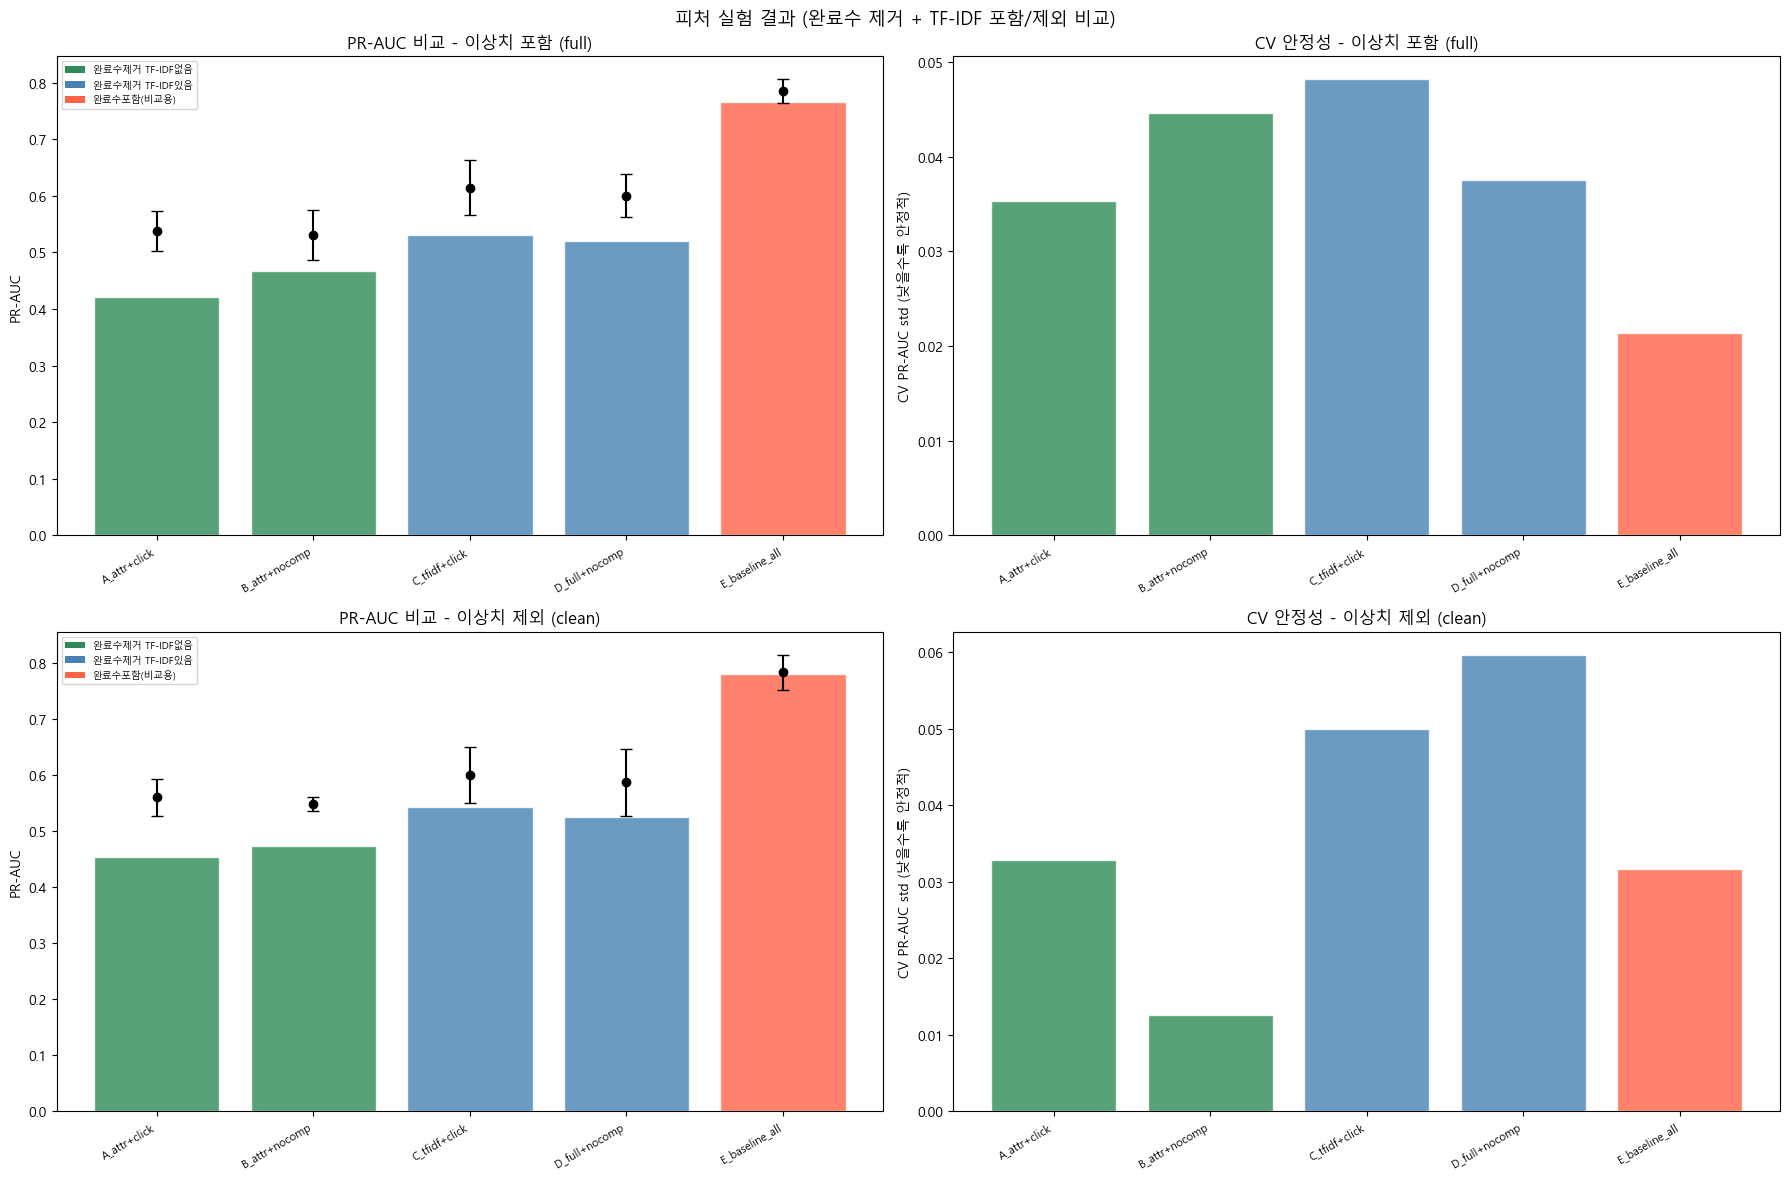


=== full 결과 (1순위: 완료수제거, 2순위: cv_prauc_mean) ===
    experiment  n_features  comp_free  has_tfidf  val_prauc  cv_prauc_mean  cv_prauc_std  roc_gap gap_status
 C_tfidf+click         101       True       True     0.5299         0.6141        0.0482   0.1469    CAUTION
 D_full+nocomp         105       True       True     0.5193         0.6002        0.0375   0.1634       RISK
  A_attr+click          51       True      False     0.4212         0.5376        0.0353   0.1759       RISK
 B_attr+nocomp          55       True      False     0.4666         0.5310        0.0446   0.1958       RISK
E_baseline_all         109      False       True     0.7657         0.7850        0.0214   0.0624       SAFE


In [6]:

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('피처 실험 결과 (완료수 제거 + TF-IDF 포함/제외 비교)', fontsize=13)

for row, (result, version) in enumerate([
    (result_full,  '이상치 포함 (full)'),
    (result_clean, '이상치 제외 (clean)'),
]):
    x = range(len(result))
    colors = []
    for _, r in result.iterrows():
        if not r['comp_free']:
            colors.append('tomato')
        elif r['has_tfidf']:
            colors.append('steelblue')
        else:
            colors.append('seagreen')

    ax = axes[row][0]
    ax.bar(x, result['val_prauc'], color=colors, alpha=0.8, edgecolor='white')
    ax.errorbar(x, result['cv_prauc_mean'], yerr=result['cv_prauc_std'],
                fmt='o', color='black', capsize=4, label='CV PR-AUC')
    ax.set_xticks(x)
    ax.set_xticklabels(result['experiment'], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('PR-AUC')
    ax.set_title(f'PR-AUC 비교 - {version}')
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor='seagreen',  label='완료수제거 TF-IDF없음'),
        Patch(facecolor='steelblue', label='완료수제거 TF-IDF있음'),
        Patch(facecolor='tomato',    label='완료수포함(비교용)'),
    ], fontsize=7)

    ax = axes[row][1]
    ax.bar(x, result['cv_prauc_std'], color=colors, alpha=0.8, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(result['experiment'], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('CV PR-AUC std (낮을수록 안정적)')
    ax.set_title(f'CV 안정성 - {version}')

plt.tight_layout()
plt.show()

print("\n=== full 결과 (1순위: 완료수제거, 2순위: cv_prauc_mean) ===")
r = result_full.sort_values(['comp_free','cv_prauc_mean'], ascending=[False,False])
print(r[['experiment','n_features','comp_free','has_tfidf','val_prauc',
          'cv_prauc_mean','cv_prauc_std','roc_gap','gap_status']].to_string(index=False))


## 4. 최적 피처 선정

In [7]:

def select_best(result_df):
    # 완료수 제거 실험 중에서만 선택
    cands = result_df[result_df['comp_free'] == True].copy()
    if cands.empty:
        cands = result_df
    # CV PR-AUC 평균 우선, std 낮을수록 안정적
    best = cands.sort_values(
        ['cv_prauc_mean', 'cv_prauc_std'],
        ascending=[False, True]
    ).iloc[0]
    return best

best_full  = select_best(result_full)
best_clean = select_best(result_clean)

print(f"[full]  최적: {best_full['experiment']} | cv={best_full['cv_prauc_mean']:.4f}±{best_full['cv_prauc_std']:.4f}")
print(f"[clean] 최적: {best_clean['experiment']} | cv={best_clean['cv_prauc_mean']:.4f}±{best_clean['cv_prauc_std']:.4f}")

BEST_EXP_FULL  = best_full['experiment']
BEST_EXP_CLEAN = best_clean['experiment']
BEST_FEATS_FULL  = [f for f in FEATURE_SETS[BEST_EXP_FULL]  if f in train.columns]
BEST_FEATS_CLEAN = [f for f in FEATURE_SETS[BEST_EXP_CLEAN] if f in train.columns]

comp_check = [f for f in BEST_FEATS_FULL + BEST_FEATS_CLEAN if 'complete' in f]
assert len(comp_check) == 0, f"완료수 계열 포함됨: {comp_check}"
print("OK: 최종 피처에 완료수 계열 없음")

ratio_full  = len(train_full)  / len(BEST_FEATS_FULL)
ratio_clean = len(train_clean) / len(BEST_FEATS_CLEAN)
print(f"\n샘플/피처 비율 (full):  {ratio_full:.1f}:1")
print(f"샘플/피처 비율 (clean): {ratio_clean:.1f}:1")
print(f"(목표 30:1 이상, 현재 {'충족' if min(ratio_full, ratio_clean) >= 30 else '미충족'})")


[full]  최적: C_tfidf+click | cv=0.6141±0.0482
[clean] 최적: C_tfidf+click | cv=0.6002±0.0500
OK: 최종 피처에 완료수 계열 없음

샘플/피처 비율 (full):  15.5:1
샘플/피처 비율 (clean): 15.2:1
(목표 30:1 이상, 현재 미충족)


## 5. 모델 비교 (val 기준, PR-AUC 우선)

In [8]:

def compare_models(train_df, val_df, features, version_name, cv=CV, seed=42):
    X_tr = train_df[features]
    y_tr = train_df['label']
    X_va = val_df[features]
    y_va = val_df['label']

    neg = (y_tr == 0).sum()
    pos = (y_tr == 1).sum()
    spw = neg / pos

    models = {
        'LR':   Pipeline([('sc', StandardScaler()),
                           ('clf', LogisticRegression(class_weight='balanced',
                                                       max_iter=1000, random_state=seed))]),
        'LGBM': LGBMClassifier(n_estimators=300, scale_pos_weight=spw,
                                random_state=seed, verbose=-1, n_jobs=-1),
        'XGB':  XGBClassifier(n_estimators=300, scale_pos_weight=spw,
                               eval_metric='logloss', random_state=seed,
                               verbosity=0, n_jobs=-1),
        'RF':   RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                        random_state=seed, n_jobs=-1),
    }

    results, fitted, probas = [], {}, {}
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        tr_p   = model.predict_proba(X_tr)[:, 1]
        va_p   = model.predict_proba(X_va)[:, 1]
        va_pred= (va_p >= 0.5).astype(int)

        tr_auc   = roc_auc_score(y_tr, tr_p)
        va_auc   = roc_auc_score(y_va, va_p)
        va_prauc = average_precision_score(y_va, va_p)
        va_recall= recall_score(y_va, va_pred)
        va_f1    = f1_score(y_va, va_pred)
        cv_prauc = cross_val_score(model, X_tr, y_tr, cv=cv,
                                    scoring='average_precision', n_jobs=-1)
        roc_gap  = tr_auc - va_auc
        gap_status = 'SAFE' if roc_gap<=0.10 else 'CAUTION' if roc_gap<=0.15 else 'RISK'

        results.append({
            'version': version_name, 'model': name,
            'train_auc':    round(tr_auc, 4),
            'val_auc':      round(va_auc, 4),
            'val_prauc':    round(va_prauc, 4),
            'val_recall':   round(va_recall, 4),
            'val_f1':       round(va_f1, 4),
            'cv_prauc_mean':round(cv_prauc.mean(), 4),
            'cv_prauc_std': round(cv_prauc.std(), 4),
            'cv_prauc_min': round(cv_prauc.min(), 4),
            'cv_prauc_max': round(cv_prauc.max(), 4),
            'roc_gap':      round(roc_gap, 4),
            'gap_status':   gap_status,
        })
        fitted[name] = model
        probas[name] = va_p
        print(f"  {name}: val_prauc={va_prauc:.4f} | recall={va_recall:.4f} | "
              f"cv={cv_prauc.mean():.4f}±{cv_prauc.std():.4f} | roc_gap={roc_gap:.4f} [{gap_status}]")

    return pd.DataFrame(results), fitted, probas, X_va, y_va

print("=== 모델 비교 (full) ===")
df_cmp_full, models_full, probas_full, X_va_full, y_va_full = compare_models(
    train_full, val_full, BEST_FEATS_FULL, 'full')

print("\n=== 모델 비교 (clean) ===")
df_cmp_clean, models_clean, probas_clean, X_va_clean, y_va_clean = compare_models(
    train_clean, val_clean, BEST_FEATS_CLEAN, 'clean')

df_all = pd.concat([df_cmp_full, df_cmp_clean], ignore_index=True)
print("\n=== 전체 모델 비교 (cv_prauc_mean 정렬) ===")
print(df_all[['version','model','val_prauc','val_recall','cv_prauc_mean',
               'cv_prauc_std','cv_prauc_min','cv_prauc_max','roc_gap','gap_status']]
      .sort_values('cv_prauc_mean', ascending=False).to_string(index=False))


=== 모델 비교 (full) ===
  LR: val_prauc=0.3727 | recall=0.5077 | cv=0.3956±0.0565 | roc_gap=0.1154 [CAUTION]
  LGBM: val_prauc=0.5299 | recall=0.4769 | cv=0.6141±0.0482 | roc_gap=0.1469 [CAUTION]
  XGB: val_prauc=0.5679 | recall=0.4769 | cv=0.5985±0.0537 | roc_gap=0.1307 [CAUTION]
  RF: val_prauc=0.5244 | recall=0.3692 | cv=0.5878±0.0575 | roc_gap=0.1530 [RISK]

=== 모델 비교 (clean) ===
  LR: val_prauc=0.3864 | recall=0.5781 | cv=0.4758±0.0812 | roc_gap=0.1139 [CAUTION]
  LGBM: val_prauc=0.5427 | recall=0.5000 | cv=0.6002±0.0500 | roc_gap=0.1424 [CAUTION]
  XGB: val_prauc=0.5476 | recall=0.5156 | cv=0.5874±0.0519 | roc_gap=0.1313 [CAUTION]
  RF: val_prauc=0.5437 | recall=0.4375 | cv=0.5981±0.0693 | roc_gap=0.1613 [RISK]

=== 전체 모델 비교 (cv_prauc_mean 정렬) ===
version model  val_prauc  val_recall  cv_prauc_mean  cv_prauc_std  cv_prauc_min  cv_prauc_max  roc_gap gap_status
   full  LGBM     0.5299      0.4769         0.6141        0.0482        0.5595        0.6706   0.1469    CAUTION
  clean  LG

## 6. 과적합 점검 (Learning Curve, PR-AUC 기준)

Learning Curve에서 Train PR-AUC와 CV PR-AUC 간 gap을 확인한다.
RF는 Train PR-AUC가 1.0에 고정되는 구조적 특성이 있어 gap이 과대 표시된다.
LGBM은 Train이 1.0에 고정되지 않아 gap 해석이 더 명확하다.


full  최고 모델: LGBM
clean 최고 모델: LGBM


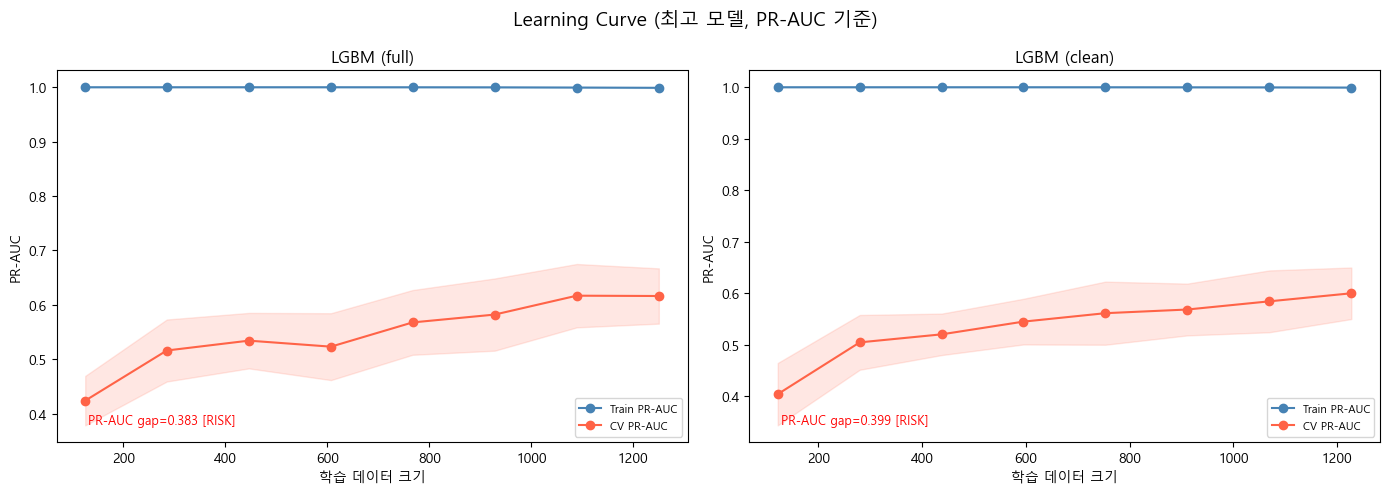

In [9]:

best_name_full  = df_cmp_full.sort_values('cv_prauc_mean', ascending=False).iloc[0]['model']
best_name_clean = df_cmp_clean.sort_values('cv_prauc_mean', ascending=False).iloc[0]['model']
print(f"full  최고 모델: {best_name_full}")
print(f"clean 최고 모델: {best_name_clean}")

def plot_lc(model, X, y, title, ax, cv=CV):
    sizes, tr_s, cv_s = learning_curve(
        model, X, y, cv=cv, scoring='average_precision',
        train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
    )
    tr_m, tr_std = tr_s.mean(1), tr_s.std(1)
    cv_m, cv_std = cv_s.mean(1), cv_s.std(1)

    ax.plot(sizes, tr_m, 'o-', color='steelblue', label='Train PR-AUC')
    ax.fill_between(sizes, tr_m-tr_std, tr_m+tr_std, alpha=0.15, color='steelblue')
    ax.plot(sizes, cv_m, 'o-', color='tomato', label='CV PR-AUC')
    ax.fill_between(sizes, cv_m-cv_std, cv_m+cv_std, alpha=0.15, color='tomato')
    ax.set_xlabel('학습 데이터 크기')
    ax.set_ylabel('PR-AUC')
    ax.set_title(title)
    ax.legend(fontsize=8)

    gap = tr_m[-1] - cv_m[-1]
    color  = 'green' if gap<=0.10 else 'goldenrod' if gap<=0.15 else 'red'
    status = 'SAFE' if gap<=0.10 else 'CAUTION' if gap<=0.15 else 'RISK'
    ax.text(0.05, 0.05, f'PR-AUC gap={gap:.3f} [{status}]',
            transform=ax.transAxes, color=color, fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curve (최고 모델, PR-AUC 기준)', fontsize=14)
plot_lc(models_full[best_name_full],
        train_full[BEST_FEATS_FULL], train_full['label'],
        f'{best_name_full} (full)', axes[0])
plot_lc(models_clean[best_name_clean],
        train_clean[BEST_FEATS_CLEAN], train_clean['label'],
        f'{best_name_clean} (clean)', axes[1])
plt.tight_layout()
plt.show()


## 7. 최종 모델 선정

선정 기준: CV PR-AUC 평균 우선, std 낮을수록 안정적.
이 단계까지의 결과(train/CV/val)로 최종 모델을 확정한다.
이후 Optuna 튜닝(Step 8)도 val 기준 CV PR-AUC를 목적함수로 둔다.

test는 Step 9에서 딱 한 번 성능 확인 용도로만 사용하며,
모델 선정·하이퍼파라미터·threshold 결정의 근거로 사용하지 않는다.


In [10]:

# CV PR-AUC 평균 우선, std 낮을수록 안정적
final_row = df_all.sort_values(
    ['cv_prauc_mean', 'cv_prauc_std'],
    ascending=[False, True]
).iloc[0]

FINAL_VERSION   = final_row['version']
FINAL_MODEL     = final_row['model']

print(f"최종 선정: [{FINAL_VERSION}] {FINAL_MODEL}")
print(f"  선정 근거: CV PR-AUC (test 미사용)")
print(f"  val PR-AUC:     {final_row['val_prauc']:.4f}")
print(f"  val Recall:     {final_row['val_recall']:.4f}")
print(f"  cv PR-AUC:      {final_row['cv_prauc_mean']:.4f} ± {final_row['cv_prauc_std']:.4f}")
print(f"  cv range:       [{final_row['cv_prauc_min']:.3f} ~ {final_row['cv_prauc_max']:.3f}]")
print(f"  train-val ROC gap: {final_row['roc_gap']:.4f} [{final_row['gap_status']}]")
print()
print(f"이후 Optuna 튜닝과 threshold 탐색은 val 기준으로 진행하며,")
print(f"test는 Step 9에서 1회 성능 확인 용도로만 사용한다.")

if FINAL_VERSION == 'full':
    FINAL_TRAIN = train_full
    FINAL_VAL   = val_full
    FINAL_FEATS = BEST_FEATS_FULL
    FINAL_MODEL_OBJ = models_full[FINAL_MODEL]
else:
    FINAL_TRAIN = train_clean
    FINAL_VAL   = val_clean
    FINAL_FEATS = BEST_FEATS_CLEAN
    FINAL_MODEL_OBJ = models_clean[FINAL_MODEL]

comp_check = [f for f in FINAL_FEATS if 'complete' in f]
assert len(comp_check) == 0, f"완료수 계열 포함됨: {comp_check}"
print("\nOK: 최종 피처에 완료수 계열 없음")


최종 선정: [full] LGBM
  선정 근거: CV PR-AUC (test 미사용)
  val PR-AUC:     0.5299
  val Recall:     0.4769
  cv PR-AUC:      0.6141 ± 0.0482
  cv range:       [0.559 ~ 0.671]
  train-val ROC gap: 0.1469 [CAUTION]

이후 Optuna 튜닝과 threshold 탐색은 val 기준으로 진행하며,
test는 Step 9에서 1회 성능 확인 용도로만 사용한다.

OK: 최종 피처에 완료수 계열 없음


## 8. Optuna 튜닝 (val 기준, PR-AUC 기준)

정규화 강화 방향으로 탐색:
- num_leaves: 낮게 제한 (15~31) -> 트리 복잡도 축소
- max_depth: 상한 제한 (3~6)
- min_child_samples: 크게 (20~100) -> 리프 노드 최소 샘플 증가
- feature_fraction/bagging_fraction: 낮게 (0.4~0.8) -> 다양성 확보
- lambda_l1/lambda_l2: 넓은 범위 탐색 -> L1/L2 정규화 강화
- min_gain_to_split: 양수 범위 탐색 -> 불필요한 분기 억제


In [11]:
import lightgbm as lgb
import json
import os

X_tune = FINAL_TRAIN[FINAL_FEATS]
y_tune = FINAL_TRAIN['label']
X_va_f = FINAL_VAL[FINAL_FEATS]
y_va_f = FINAL_VAL['label']

neg = (y_tune == 0).sum()
pos = (y_tune == 1).sum()
spw = neg / pos

BEST_PARAMS_PATH = 'model2_best_params.json'

# FINAL_MODEL에 따라 Optuna objective를 분기
# 피처 선정 단계에서 선택된 모델이 무엇이든 그에 맞는 튜닝을 수행한다
def objective_lgbm(trial):
    p = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 250),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 6),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 31),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.4, 0.8),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.4, 0.8),
        'bagging_freq':      trial.suggest_int('bagging_freq', 1, 5),
        'lambda_l1':         trial.suggest_float('lambda_l1', 1e-6, 10.0, log=True),
        'lambda_l2':         trial.suggest_float('lambda_l2', 1e-6, 10.0, log=True),
        'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 1.0),
        'scale_pos_weight': spw,
        'random_state': SEED, 'verbose': -1, 'n_jobs': -1,
    }
    fold_scores = []
    for tr_idx, va_idx in CV.split(X_tune, y_tune):
        X_fold_tr, X_fold_va = X_tune.iloc[tr_idx], X_tune.iloc[va_idx]
        y_fold_tr, y_fold_va = y_tune.iloc[tr_idx], y_tune.iloc[va_idx]
        model = LGBMClassifier(**p)
        model.fit(
            X_fold_tr, y_fold_tr,
            eval_set=[(X_fold_va, y_fold_va)],
            eval_metric='average_precision',
            callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
        )
        proba = model.predict_proba(X_fold_va)[:, 1]
        fold_scores.append(average_precision_score(y_fold_va, proba))
    return np.mean(fold_scores)

def objective_xgb(trial):
    p = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-6, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-6, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'scale_pos_weight': spw, 'eval_metric': 'logloss',
        'random_state': SEED, 'verbosity': 0, 'n_jobs': -1,
    }
    return cross_val_score(XGBClassifier(**p), X_tune, y_tune,
                           cv=CV, scoring='average_precision', n_jobs=-1).mean()

def objective_rf(trial):
    p = {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 500),
        'max_depth':     trial.suggest_int('max_depth', 3, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),
        'max_features':  trial.suggest_float('max_features', 0.3, 1.0),
        'class_weight': 'balanced', 'random_state': SEED, 'n_jobs': -1,
    }
    return cross_val_score(RandomForestClassifier(**p), X_tune, y_tune,
                           cv=CV, scoring='average_precision', n_jobs=-1).mean()

def objective_lr(trial):
    p = {
        'C':         trial.suggest_float('C', 1e-3, 10.0, log=True),
        'max_iter':  1000,
        'class_weight': 'balanced', 'random_state': SEED,
    }
    return cross_val_score(
        Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(**p))]),
        X_tune, y_tune, cv=CV, scoring='average_precision', n_jobs=-1
    ).mean()

objective_map = {
    'LGBM': objective_lgbm,
    'XGB':  objective_xgb,
    'RF':   objective_rf,
    'LR':   objective_lr,
}
objective = objective_map[FINAL_MODEL]
print(f"최종 모델 [{FINAL_MODEL}] 기준으로 Optuna 튜닝 진행")

# best_params JSON이 존재하면 재사용, 없으면 Optuna 실행 후 저장
# (재실행 간 미세 변동을 막아 보고서-노트북 수치를 일치시키는 단일 진실 소스 역할)
if os.path.exists(BEST_PARAMS_PATH):
    with open(BEST_PARAMS_PATH, 'r') as f:
        best_params_raw = json.load(f)
    print(f"기존 best_params 로드: {BEST_PARAMS_PATH}")
    print(f"(Optuna 재실행을 원하면 해당 파일을 삭제하고 셀을 다시 실행)")
    # 로드된 파라미터로 CV PR-AUC 재현
    # FINAL_MODEL에 따라 각 objective와 동일한 평가 경로로 재현해야 점수가 일치한다
    if FINAL_MODEL == 'LGBM':
        fold_scores = []
        for tr_idx, va_idx in CV.split(X_tune, y_tune):
            X_fold_tr, X_fold_va = X_tune.iloc[tr_idx], X_tune.iloc[va_idx]
            y_fold_tr, y_fold_va = y_tune.iloc[tr_idx], y_tune.iloc[va_idx]
            m = LGBMClassifier(**best_params_raw, scale_pos_weight=spw,
                               random_state=SEED, verbose=-1, n_jobs=-1)
            m.fit(X_fold_tr, y_fold_tr,
                  eval_set=[(X_fold_va, y_fold_va)],
                  eval_metric='average_precision',
                  callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)])
            fold_scores.append(average_precision_score(y_fold_va, m.predict_proba(X_fold_va)[:,1]))
        best_cv_value = float(np.mean(fold_scores))
    elif FINAL_MODEL == 'XGB':
        m = XGBClassifier(**best_params_raw, scale_pos_weight=spw, eval_metric='logloss',
                          random_state=SEED, verbosity=0, n_jobs=-1)
        best_cv_value = float(cross_val_score(m, X_tune, y_tune,
                                              cv=CV, scoring='average_precision', n_jobs=-1).mean())
    elif FINAL_MODEL == 'RF':
        m = RandomForestClassifier(**best_params_raw, class_weight='balanced',
                                   random_state=SEED, n_jobs=-1)
        best_cv_value = float(cross_val_score(m, X_tune, y_tune,
                                              cv=CV, scoring='average_precision', n_jobs=-1).mean())
    elif FINAL_MODEL == 'LR':
        m = Pipeline([('sc', StandardScaler()),
                      ('clf', LogisticRegression(**best_params_raw, max_iter=1000,
                                                 class_weight='balanced', random_state=SEED))])
        best_cv_value = float(cross_val_score(m, X_tune, y_tune,
                                              cv=CV, scoring='average_precision', n_jobs=-1).mean())
    else:
        raise ValueError(f"지원하지 않는 FINAL_MODEL: {FINAL_MODEL}")
    print(f"CV PR-AUC (재현, {FINAL_MODEL}): {best_cv_value:.4f}")
else:
    # FINAL_MODEL에 맞는 objective로 신규 튜닝
    # (LGBM만 early_stopping 사용, XGB/RF/LR은 cross_val_score 경로)
    print(f"{FINAL_MODEL} Optuna 튜닝 시작 (100 trials)...")
    study = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=100, show_progress_bar=True)
    best_params_raw = study.best_params
    best_cv_value   = study.best_value
    print(f"\n최적 CV PR-AUC: {best_cv_value:.4f}")

    with open(BEST_PARAMS_PATH, 'w') as f:
        json.dump(best_params_raw, f, indent=2)
    print(f"best_params 저장: {BEST_PARAMS_PATH}")

print(f"\n[best_params]")
for k, v in best_params_raw.items():
    print(f"  {k}: {v}")


최종 모델 [LGBM] 기준으로 Optuna 튜닝 진행
기존 best_params 로드: model2_best_params.json
(Optuna 재실행을 원하면 해당 파일을 삭제하고 셀을 다시 실행)
CV PR-AUC (재현, LGBM): 0.6185

[best_params]
  n_estimators: 234
  learning_rate: 0.013654801962309285
  max_depth: 5
  num_leaves: 23
  min_child_samples: 20
  feature_fraction: 0.588198606965299
  bagging_fraction: 0.5929345494395346
  bagging_freq: 1
  lambda_l1: 4.569501806140246e-06
  lambda_l2: 1.505181311799353e-05
  min_gain_to_split: 0.5463023888259795


In [12]:

# 저장된 best_params_raw로 FINAL_MODEL에 맞는 모델 빌드
best_params = best_params_raw.copy()
if FINAL_MODEL == 'LGBM':
    best_params.update({'scale_pos_weight': spw, 'random_state': SEED,
                         'verbose': -1, 'n_jobs': -1})
    tuned_model = LGBMClassifier(**best_params)
elif FINAL_MODEL == 'XGB':
    best_params.update({'scale_pos_weight': spw, 'eval_metric': 'logloss',
                         'random_state': SEED, 'verbosity': 0, 'n_jobs': -1})
    tuned_model = XGBClassifier(**best_params)
elif FINAL_MODEL == 'RF':
    best_params.update({'class_weight': 'balanced', 'random_state': SEED, 'n_jobs': -1})
    tuned_model = RandomForestClassifier(**best_params)
elif FINAL_MODEL == 'LR':
    best_params.update({'class_weight': 'balanced', 'random_state': SEED, 'max_iter': 1000})
    tuned_model = Pipeline([('sc', StandardScaler()),
                             ('clf', LogisticRegression(**best_params))])
else:
    raise ValueError(f"지원하지 않는 모델: {FINAL_MODEL}")

tuned_model.fit(X_tune, y_tune)
print(f"tuned_model 빌드 완료: [{FINAL_VERSION}] {FINAL_MODEL}")

va_proba_tuned  = tuned_model.predict_proba(X_va_f)[:, 1]
tr_proba_tuned  = tuned_model.predict_proba(X_tune)[:, 1]
va_proba_before = FINAL_MODEL_OBJ.predict_proba(X_va_f)[:, 1]

# gap 지표: ROC-AUC 기준과 PR-AUC 기준 분리
roc_gap_tuned     = roc_auc_score(y_tune, tr_proba_tuned) - roc_auc_score(y_va_f, va_proba_tuned)
cv_prauc_mean     = best_cv_value
val_prauc_tuned   = average_precision_score(y_va_f, va_proba_tuned)
prauc_gap_approx  = cv_prauc_mean - val_prauc_tuned  # CV - val 차이

# train PR-AUC와 train-val PR-AUC gap 직접 계산 (과적합 진단)
train_prauc_tuned   = average_precision_score(y_tune, tr_proba_tuned)
trainval_prauc_gap  = train_prauc_tuned - val_prauc_tuned

print("[튜닝 전후 val 성능 비교]")
print(f"  val PR-AUC: {average_precision_score(y_va_f, va_proba_before):.4f} -> {val_prauc_tuned:.4f}")
print(f"  val Recall: {recall_score(y_va_f, (va_proba_before>=0.5).astype(int)):.4f} -> {recall_score(y_va_f, (va_proba_tuned>=0.5).astype(int)):.4f}")
print(f"  val AUC:    {roc_auc_score(y_va_f, va_proba_before):.4f} -> {roc_auc_score(y_va_f, va_proba_tuned):.4f}")

print(f"\n[gap 지표 분리 — ROC-AUC 기준과 PR-AUC 기준 구분]")
print(f"  train-val ROC-AUC gap: {roc_gap_tuned:.4f} ({'SAFE' if roc_gap_tuned<=0.10 else 'CAUTION' if roc_gap_tuned<=0.15 else 'RISK'})")
print(f"  CV PR-AUC:             {cv_prauc_mean:.4f}")
print(f"  val PR-AUC:            {val_prauc_tuned:.4f}")
print(f"  CV-val PR-AUC 차이:    {prauc_gap_approx:+.4f}")

print(f"\n[과적합 진단 — train-val PR-AUC gap]")
print(f"  train PR-AUC:         {train_prauc_tuned:.4f}")
print(f"  val PR-AUC:           {val_prauc_tuned:.4f}")
print(f"  train-val PR-AUC gap: {trainval_prauc_gap:.4f} ({'SAFE' if trainval_prauc_gap<=0.10 else 'CAUTION' if trainval_prauc_gap<=0.15 else 'RISK'})")
print(f"  해석: PR-AUC 기준 train-val gap은 여전히 크게 관찰되며 잔존 과적합 가능성 존재.")
print(f"        다만 ROC-AUC 기준 train-test gap과 CV-test PR-AUC 차이는 Step 9에서 별도 확인.")


tuned_model 빌드 완료: [full] LGBM
[튜닝 전후 val 성능 비교]
  val PR-AUC: 0.5299 -> 0.5572
  val Recall: 0.4769 -> 0.7077
  val AUC:    0.8528 -> 0.8550

[gap 지표 분리 — ROC-AUC 기준과 PR-AUC 기준 구분]
  train-val ROC-AUC gap: 0.0969 (SAFE)
  CV PR-AUC:             0.6185
  val PR-AUC:            0.5572
  CV-val PR-AUC 차이:    +0.0613

[과적합 진단 — train-val PR-AUC gap]
  train PR-AUC:         0.8197
  val PR-AUC:           0.5572
  train-val PR-AUC gap: 0.2625 (RISK)
  해석: PR-AUC 기준 train-val gap은 여전히 크게 관찰되며 잔존 과적합 가능성 존재.
        다만 ROC-AUC 기준 train-test gap과 CV-test PR-AUC 차이는 Step 9에서 별도 확인.


## 9. 최종 평가 (test — 딱 한 번)

이 단계는 모델 선정·하이퍼파라미터·threshold 결정이 모두 끝난 뒤
최종 성능을 확인하는 용도로만 사용한다.
test 결과를 보고 모델·threshold·피처를 다시 변경하지 않는다.

PR-AUC 기준 train-val gap은 여전히 크게 관찰되므로 잔존 과적합 가능성은 남아 있다.
다만 ROC-AUC 기준 train-test gap과 CV-test PR-AUC 차이가 안정적으로 나타나면,
현재 단계에서는 운영자 우선순위화 보조 모델로 사용 가능한 수준으로 판단할 수 있다.


[최종 test 결과 — threshold 0.5 기준]
  test AUC-ROC:    0.8548
  test PR-AUC:     0.6009
  test Precision:  0.4351
  test Recall:     0.6706
  test F1:         0.5278

[gap 지표 분리]
  train-test ROC-AUC gap: 0.0971 (SAFE)
  CV PR-AUC:              0.6185
  test PR-AUC:            0.6009
  CV-test PR-AUC 차이:    +0.0176

[종합 해석]
  PR-AUC 기준 train-val gap은 여전히 크게 관찰되어 잔존 과적합 가능성은 있으나,
  ROC-AUC 기준 train-test gap과 CV-test PR-AUC 차이가 안정적으로 나타나
  운영자 우선순위화 보조 모델로 사용 가능한 수준으로 판단.

판단 보류: 528건 -> rule 기반 별도 관리


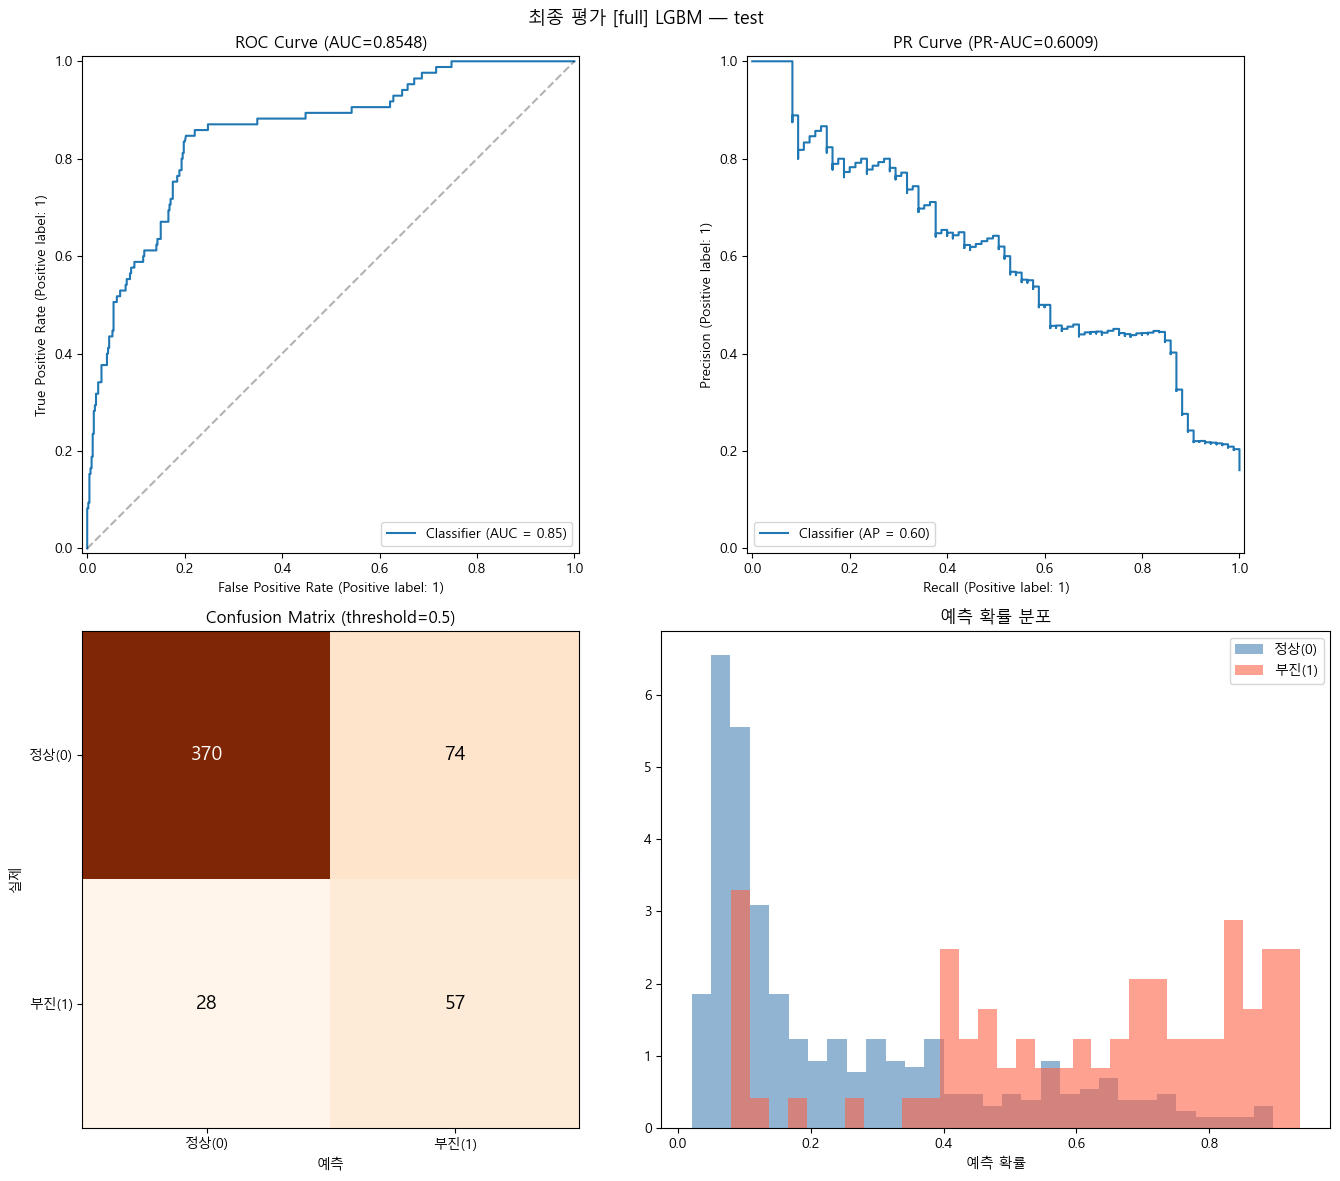


=== Classification Report ===
              precision    recall  f1-score   support

       정상(0)       0.93      0.83      0.88       444
       부진(1)       0.44      0.67      0.53        85

    accuracy                           0.81       529
   macro avg       0.68      0.75      0.70       529
weighted avg       0.85      0.81      0.82       529



In [13]:

if FINAL_VERSION == 'full':
    test_final = test.copy()
else:
    test_final = test[test['is_outlier'] == 0].copy()

X_test_final = test_final[FINAL_FEATS]
y_test_final = test_final['label']

te_proba = tuned_model.predict_proba(X_test_final)[:, 1]
te_pred  = (te_proba >= 0.5).astype(int)
te_auc   = roc_auc_score(y_test_final, te_proba)
te_prauc = average_precision_score(y_test_final, te_proba)
te_recall= recall_score(y_test_final, te_pred)
te_f1    = f1_score(y_test_final, te_pred)
te_precision = precision_score(y_test_final, te_pred, zero_division=0)

# gap 지표 분리 출력
train_roc_auc     = roc_auc_score(y_tune, tr_proba_tuned)
te_roc_gap        = train_roc_auc - te_auc
cv_test_prauc_gap = cv_prauc_mean - te_prauc

print(f"[최종 test 결과 — threshold 0.5 기준]")
print(f"  test AUC-ROC:    {te_auc:.4f}")
print(f"  test PR-AUC:     {te_prauc:.4f}")
print(f"  test Precision:  {te_precision:.4f}")
print(f"  test Recall:     {te_recall:.4f}")
print(f"  test F1:         {te_f1:.4f}")

print(f"\n[gap 지표 분리]")
print(f"  train-test ROC-AUC gap: {te_roc_gap:.4f} ({'SAFE' if te_roc_gap<=0.10 else 'CAUTION' if te_roc_gap<=0.15 else 'RISK'})")
print(f"  CV PR-AUC:              {cv_prauc_mean:.4f}")
print(f"  test PR-AUC:            {te_prauc:.4f}")
print(f"  CV-test PR-AUC 차이:    {cv_test_prauc_gap:+.4f}")

print(f"\n[종합 해석]")
print(f"  PR-AUC 기준 train-val gap은 여전히 크게 관찰되어 잔존 과적합 가능성은 있으나,")
print(f"  ROC-AUC 기준 train-test gap과 CV-test PR-AUC 차이가 안정적으로 나타나")
print(f"  운영자 우선순위화 보조 모델로 사용 가능한 수준으로 판단.")

print(f"\n판단 보류: {len(test_raw)-len(test):,}건 -> rule 기반 별도 관리")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(f'최종 평가 [{FINAL_VERSION}] {FINAL_MODEL} — test', fontsize=13)

RocCurveDisplay.from_predictions(y_test_final, te_proba, ax=axes[0][0])
axes[0][0].plot([0,1],[0,1],'k--',alpha=0.3)
axes[0][0].set_title(f'ROC Curve (AUC={te_auc:.4f})')

PrecisionRecallDisplay.from_predictions(y_test_final, te_proba, ax=axes[0][1])
axes[0][1].set_title(f'PR Curve (PR-AUC={te_prauc:.4f})')

cm = confusion_matrix(y_test_final, te_pred)
axes[1][0].imshow(cm, cmap='Oranges')
axes[1][0].set_xticks([0,1])
axes[1][0].set_yticks([0,1])
axes[1][0].set_xticklabels(['정상(0)','부진(1)'])
axes[1][0].set_yticklabels(['정상(0)','부진(1)'])
axes[1][0].set_xlabel('예측')
axes[1][0].set_ylabel('실제')
axes[1][0].set_title('Confusion Matrix (threshold=0.5)')
for i in range(2):
    for j in range(2):
        axes[1][0].text(j, i, str(cm[i,j]), ha='center', va='center',
                         fontsize=14, color='white' if cm[i,j]>cm.max()/2 else 'black')

axes[1][1].hist(te_proba[y_test_final==0], bins=30, alpha=0.6,
                 color='steelblue', label='정상(0)', density=True)
axes[1][1].hist(te_proba[y_test_final==1], bins=30, alpha=0.6,
                 color='tomato', label='부진(1)', density=True)
axes[1][1].set_xlabel('예측 확률')
axes[1][1].set_title('예측 확률 분포')
axes[1][1].legend()

plt.tight_layout()
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_test_final, te_pred,
                              target_names=['정상(0)','부진(1)']))


## 10. SHAP 해석 (early_click 의존도 정량화)

단일 피처에 대한 과도한 의존이 있으면 모델이 복잡한 패턴을 학습하지 못하고
단순 규칙에 가까운 예측을 한다는 신호일 수 있다.
early_click이 전체 SHAP에서 차지하는 비중을 정량화해서 의존도를 확인한다.


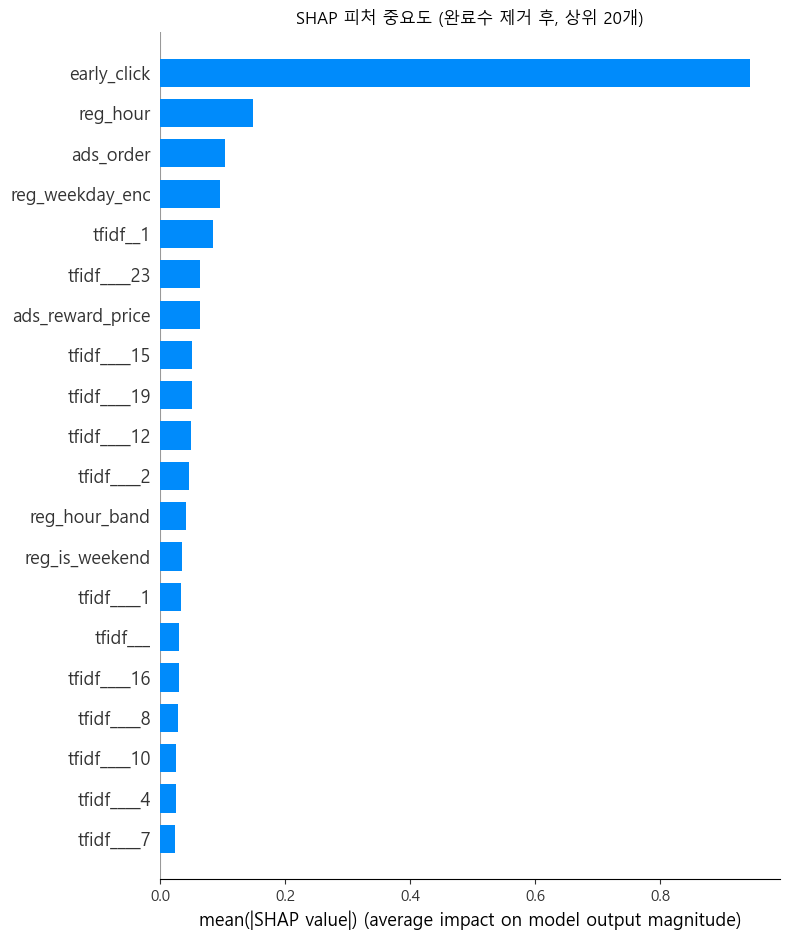

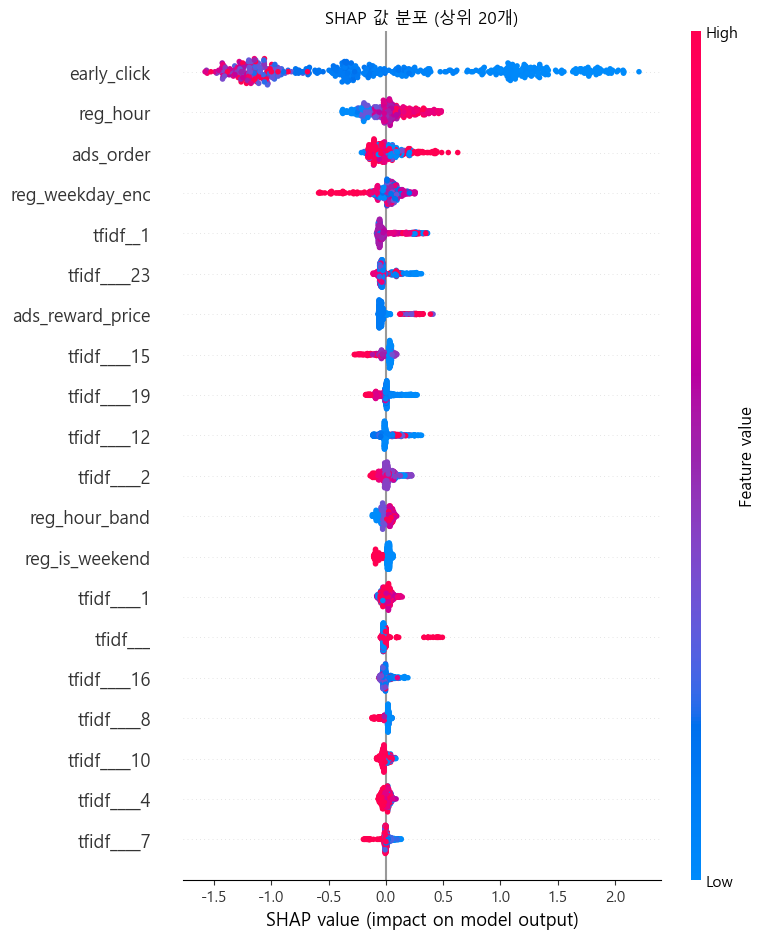


[SHAP 상위 10개 및 전체 기여 비중]
   1. early_click: 0.9445 (38.4%)
   2. reg_hour: 0.1478 (6.0%)
   3. ads_order: 0.1038 (4.2%)
   4. reg_weekday_enc: 0.0945 (3.8%)
   5. tfidf__1: 0.0844 (3.4%)
   6. tfidf____23: 0.0639 (2.6%)
   7. ads_reward_price: 0.0633 (2.6%)
   8. tfidf____15: 0.0513 (2.1%)
   9. tfidf____19: 0.0511 (2.1%)
  10. tfidf____12: 0.0492 (2.0%)

[early_click 의존도 분석]
  early_click SHAP 비중:    38.4%
  click_day 계열 SHAP 비중: 0.0%
  클릭 계열 합계:           38.4%
  경고: early_click 단일 피처 의존도 높음 (38.4%) -> 모델 단순화 가능성

OK: 완료수 계열 없음


In [14]:

try:
    import shap

    explainer   = shap.TreeExplainer(tuned_model)
    shap_values = explainer.shap_values(X_test_final)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X_test_final, plot_type='bar', show=False, max_display=20)
    plt.title('SHAP 피처 중요도 (완료수 제거 후, 상위 20개)')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X_test_final, show=False, max_display=20)
    plt.title('SHAP 값 분포 (상위 20개)')
    plt.tight_layout()
    plt.show()

    mean_abs = np.abs(sv).mean(0)
    total_shap = mean_abs.sum() + 1e-9

    top10 = sorted(zip(X_test_final.columns, mean_abs), key=lambda x: -x[1])[:10]
    print("\n[SHAP 상위 10개 및 전체 기여 비중]")
    for rank, (feat, val_s) in enumerate(top10, 1):
        pct = val_s / total_shap * 100
        warn = " <- 완료수 잔존 확인" if 'complete' in feat else ""
        print(f"  {rank:2d}. {feat}: {val_s:.4f} ({pct:.1f}%){warn}")

    # early_click 의존도 정량화
    click_shap = sum(v for f, v in zip(X_test_final.columns, mean_abs)
                      if f == 'early_click')
    click_pct  = click_shap / total_shap * 100

    click_day_shap = sum(v for f, v in zip(X_test_final.columns, mean_abs)
                          if f.startswith('click_day'))
    click_day_pct  = click_day_shap / total_shap * 100

    print(f"\n[early_click 의존도 분석]")
    print(f"  early_click SHAP 비중:    {click_pct:.1f}%")
    print(f"  click_day 계열 SHAP 비중: {click_day_pct:.1f}%")
    print(f"  클릭 계열 합계:           {click_pct + click_day_pct:.1f}%")
    if click_pct > 30:
        print(f"  경고: early_click 단일 피처 의존도 높음 ({click_pct:.1f}%) -> 모델 단순화 가능성")
    else:
        print(f"  OK: early_click 의존도 수용 가능 수준")

    comp_in_shap = [(f, v) for f, v in zip(X_test_final.columns, mean_abs)
                     if 'complete' in f]
    if comp_in_shap:
        print(f"\n경고: 완료수 계열 잔존: {comp_in_shap}")
    else:
        print("\nOK: 완료수 계열 없음")

except ImportError:
    print("pip install shap 후 재실행")


## 11. Threshold 최적화

threshold는 val 기준으로 탐색한다.
val에서 특정 recall을 목표로 탐색한 threshold를 test에 적용하면
test recall이 달라질 수 있다. val과 test 결과를 반드시 분리해서 제시한다.

예를 들어 val 기준 recall >= 0.70 threshold가 test에서는
다른 recall을 보일 수 있으므로 "recall 0.70 보장"이 아닌
"val 기준 recall 0.70 목표로 설정한 후보 threshold"로 표현해야 한다.

### threshold-별 test 성능 표의 위치
아래 표는 val에서 결정한 threshold 후보를 test에 적용한 결과이다.
모델이나 threshold를 다시 선정하기 위한 비교표가 아니라,
val에서 결정된 후보가 test에서 어떻게 동작하는지 확인하는 사후 진단용 참고표이다.
운영 threshold 최종 결정은 val 기준 탐색값과 운영 적용성으로 판단한다.


In [15]:

precision_arr, recall_arr, thresholds = precision_recall_curve(y_va_f, va_proba_tuned)

f1_arr = np.where(
    (precision_arr + recall_arr) > 0,
    2 * precision_arr * recall_arr / (precision_arr + recall_arr),
    0
)

best_f1_idx       = np.argmax(f1_arr[:-1])
best_f1_threshold = thresholds[best_f1_idx]

recall_targets = {'Recall >= 0.70': 0.70, 'Recall >= 0.80': 0.80}
recall_thresholds = {}
for label, target in recall_targets.items():
    mask = recall_arr[:-1] >= target
    if mask.any():
        idx = np.where(mask)[0][np.argmax(precision_arr[:-1][mask])]
        recall_thresholds[label] = thresholds[idx]
    else:
        recall_thresholds[label] = thresholds[0]

print("[Threshold 탐색 결과 — val 기준]")
print(f"\n[1] 현재 (threshold=0.50):")
pred_05 = (va_proba_tuned >= 0.5).astype(int)
print(f"    val: P={precision_score(y_va_f, pred_05):.4f} | R={recall_score(y_va_f, pred_05):.4f} | F1={f1_score(y_va_f, pred_05):.4f}")

print(f"\n[2] F1 최적 (threshold={best_f1_threshold:.4f}):")
pred_f1 = (va_proba_tuned >= best_f1_threshold).astype(int)
print(f"    val: P={precision_score(y_va_f, pred_f1):.4f} | R={recall_score(y_va_f, pred_f1):.4f} | F1={f1_score(y_va_f, pred_f1):.4f}")

for label, thr in recall_thresholds.items():
    pred = (va_proba_tuned >= thr).astype(int)
    print(f"\n[3] {label} 목표 후보 (threshold={thr:.4f}) — val 기준 탐색값:")
    print(f"    val: P={precision_score(y_va_f, pred):.4f} | R={recall_score(y_va_f, pred):.4f} | F1={f1_score(y_va_f, pred):.4f}")

# 상위 위험도 N% 분석 (val 기준)
print("\n[상위 위험도 N%에서 실제 부진 포함 비율 — val 기준]")
val_df_t = pd.DataFrame({'proba': va_proba_tuned, 'label': y_va_f.values})
val_df_t = val_df_t.sort_values('proba', ascending=False).reset_index(drop=True)
for pct in [0.10, 0.20, 0.30]:
    n     = int(len(val_df_t) * pct)
    top_n = val_df_t.iloc[:n]
    prec_n   = top_n['label'].mean()
    recall_n = top_n['label'].sum() / val_df_t['label'].sum()
    print(f"  상위 {int(pct*100):2d}% ({n:3d}건): P={prec_n:.4f} | R={recall_n:.4f} | 실제 부진 {int(top_n['label'].sum())}건")


[Threshold 탐색 결과 — val 기준]

[1] 현재 (threshold=0.50):
    val: P=0.3680 | R=0.7077 | F1=0.4842

[2] F1 최적 (threshold=0.5905):
    val: P=0.4615 | R=0.6462 | F1=0.5385

[3] Recall >= 0.70 목표 후보 (threshold=0.5064) — val 기준 탐색값:
    val: P=0.3740 | R=0.7077 | F1=0.4894

[3] Recall >= 0.80 목표 후보 (threshold=0.3856) — val 기준 탐색값:
    val: P=0.3059 | R=0.8000 | F1=0.4426

[상위 위험도 N%에서 실제 부진 포함 비율 — val 기준]
  상위 10% ( 50건): P=0.5600 | R=0.4308 | 실제 부진 28건
  상위 20% (100건): P=0.4200 | R=0.6462 | 실제 부진 42건
  상위 30% (150건): P=0.3333 | R=0.7692 | 실제 부진 50건


In [16]:

# val에서 결정한 threshold 후보를 test에 적용한 사후 진단표
# (모델/threshold 선정용 비교표가 아님 — 선정은 이미 val에서 끝났음)
print("[사후 진단용: val 기준 후보 threshold를 test에 적용한 결과]")
print("(이 표는 모델/threshold 선정 근거가 아니며, 운영 적용성 검토용 참고 자료)")
print(f"{'구분':<35} {'val_R':>7} {'test_P':>8} {'test_R':>8} {'test_F1':>9} {'TP':>6} {'FN':>6} {'FP':>6}")
print("-" * 90)

config_labels = ['현재(0.50)', 'F1 최적']
config_thrs   = [0.5, best_f1_threshold]
val_recalls   = [recall_score(y_va_f, (va_proba_tuned>=t).astype(int)) for t in config_thrs]

for label, thr in recall_thresholds.items():
    config_labels.append(f'{label} 후보')
    config_thrs.append(thr)
    val_recalls.append(recall_score(y_va_f, (va_proba_tuned>=thr).astype(int)))

for label, thr, val_r in zip(config_labels, config_thrs, val_recalls):
    pred = (te_proba >= thr).astype(int)
    cm_t = confusion_matrix(y_test_final, pred)
    tp = cm_t[1][1]; fn = cm_t[1][0]; fp = cm_t[0][1]
    p  = precision_score(y_test_final, pred, zero_division=0)
    r  = recall_score(y_test_final, pred, zero_division=0)
    f  = f1_score(y_test_final, pred, zero_division=0)
    print(f"{label:<35} {val_r:>7.4f} {p:>8.4f} {r:>8.4f} {f:>9.4f} {tp:>6} {fn:>6} {fp:>6}")

print("\n주의: val Recall 목표로 설정한 threshold를 test에 적용하면 test Recall이 달라진다.")
print("'Recall 0.70 보장'이 아닌 'val 기준 Recall 0.70 목표 후보 threshold'로 해석해야 함.")
print("최종 운영 threshold는 val 기준 탐색값과 운영 적용성으로 결정.")


[사후 진단용: val 기준 후보 threshold를 test에 적용한 결과]
(이 표는 모델/threshold 선정 근거가 아니며, 운영 적용성 검토용 참고 자료)
구분                                    val_R   test_P   test_R   test_F1     TP     FN     FP
------------------------------------------------------------------------------------------
현재(0.50)                             0.7077   0.4351   0.6706    0.5278     57     28     74
F1 최적                                0.6462   0.5102   0.5882    0.5464     50     35     48
Recall >= 0.70 후보                    0.7077   0.4419   0.6706    0.5327     57     28     72
Recall >= 0.80 후보                    0.8000   0.4311   0.8471    0.5714     72     13     95

주의: val Recall 목표로 설정한 threshold를 test에 적용하면 test Recall이 달라진다.
'Recall 0.70 보장'이 아닌 'val 기준 Recall 0.70 목표 후보 threshold'로 해석해야 함.
최종 운영 threshold는 val 기준 탐색값과 운영 적용성으로 결정.


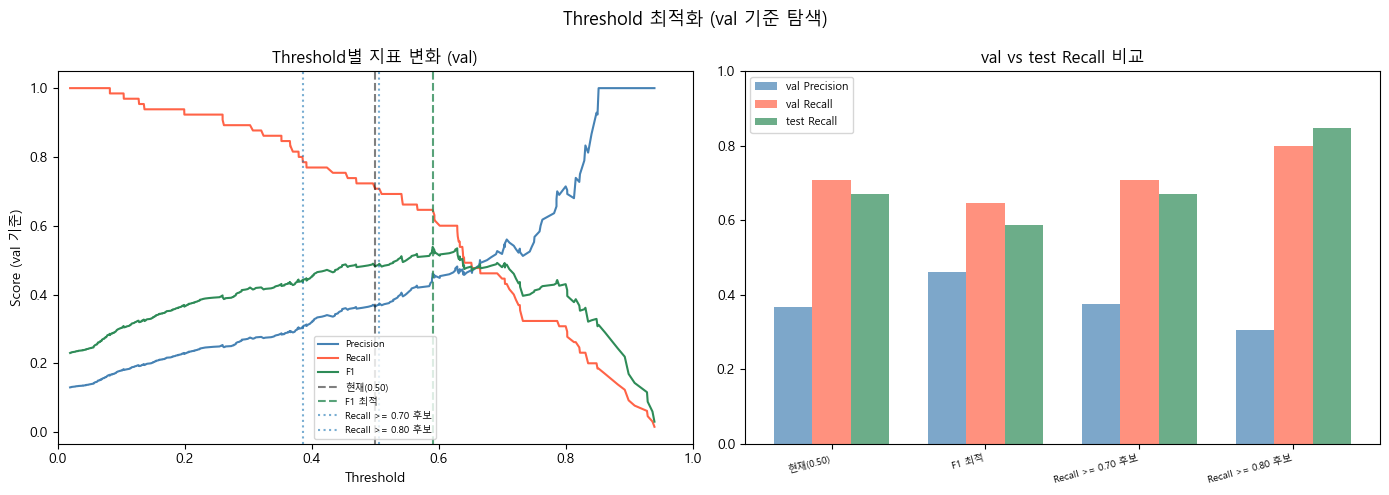

In [17]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Threshold 최적화 (val 기준 탐색)', fontsize=13)

ax = axes[0]
ax.plot(thresholds, precision_arr[:-1], color='steelblue', label='Precision')
ax.plot(thresholds, recall_arr[:-1],    color='tomato',    label='Recall')
ax.plot(thresholds, f1_arr[:-1],        color='seagreen',  label='F1')
ax.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='현재(0.50)')
ax.axvline(best_f1_threshold, color='seagreen', linestyle='--', alpha=0.8, label='F1 최적')
for label, thr in recall_thresholds.items():
    ax.axvline(thr, linestyle=':', alpha=0.6, label=f'{label} 후보')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score (val 기준)')
ax.set_title('Threshold별 지표 변화 (val)')
ax.legend(fontsize=7)
ax.set_xlim(0, 1)

ax = axes[1]
labels_plot = ['현재(0.50)', 'F1 최적'] + [f'{l} 후보' for l in recall_thresholds.keys()]
thrs_plot   = [0.5, best_f1_threshold] + list(recall_thresholds.values())
val_p_list  = [precision_score(y_va_f, (va_proba_tuned>=t).astype(int)) for t in thrs_plot]
val_r_list  = [recall_score(y_va_f,    (va_proba_tuned>=t).astype(int)) for t in thrs_plot]
test_r_list = [recall_score(y_test_final, (te_proba>=t).astype(int)) for t in thrs_plot]

x = range(len(labels_plot))
ax.bar([i-0.25 for i in x], val_p_list,  width=0.25, alpha=0.7, color='steelblue', label='val Precision')
ax.bar([i      for i in x], val_r_list,  width=0.25, alpha=0.7, color='tomato',    label='val Recall')
ax.bar([i+0.25 for i in x], test_r_list, width=0.25, alpha=0.7, color='seagreen',  label='test Recall')
ax.set_xticks(x)
ax.set_xticklabels(labels_plot, fontsize=7, rotation=15, ha='right')
ax.set_title('val vs test Recall 비교')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()


## 12. 최종 결과 요약

In [18]:

print("=" * 65)
print("Model 2 최종 결과 요약")
print("=" * 65)
print(f"\n[모델 정의]")
print(f"  D+3 시점 최종 부진 예측 (조기 경보)")
print(f"  운영 목적: 자동 의사결정이 아닌 운영자 우선순위화")
print(f"  적용 대상: early_click >= 10 광고만")
print(f"  판단 보류: early_click < 10 -> rule 기반 별도 관리")
print()
print(f"[모델 선정·평가 원칙]")
print(f"  - 모델/하이퍼파라미터/threshold는 train/CV/val로 결정")
print(f"  - test는 최종 성능 확인 1회 사용 — 선정 근거로 사용 X")
print(f"  - threshold-별 test 성능 표는 사후 진단용 참고 자료")
print()
print(f"[현재 모델 상태]")
print(f"  완료수 계열 누수는 제거 완료")
print(f"  PR-AUC 기준 train-val gap은 여전히 크게 관찰되어 잔존 과적합 가능성 존재")
print(f"  다만 ROC-AUC 기준 train-test gap과 CV-test PR-AUC 차이가 안정적으로 나타나")
print(f"  운영자 우선순위화 보조 모델로 사용 가능한 수준으로 판단")
print(f"  샘플/피처 비율: {len(FINAL_TRAIN)}/{len(FINAL_FEATS)} = {len(FINAL_TRAIN)/len(FINAL_FEATS):.1f}:1")
print()
print(f"[최종 모델]")
print(f"  [{FINAL_VERSION}] {FINAL_MODEL}")
print(f"  피처 수: {len(FINAL_FEATS)}개 (완료수 계열 없음)")
print(f"  TF-IDF: {any(f.startswith('tfidf_') for f in FINAL_FEATS)}")
print()
print(f"[성능 지표 — ROC-AUC와 PR-AUC 분리]")
print(f"  CV PR-AUC:              {cv_prauc_mean:.4f}")
print(f"  val PR-AUC:             {val_prauc_tuned:.4f}")
print(f"  test PR-AUC:            {te_prauc:.4f}")
print(f"  CV-test PR-AUC 차이:    {cv_test_prauc_gap:+.4f}")
print(f"  test AUC-ROC:           {te_auc:.4f}")
print(f"  train-test ROC-AUC gap: {te_roc_gap:.4f} ({'SAFE' if te_roc_gap<=0.10 else 'CAUTION' if te_roc_gap<=0.15 else 'RISK'})")
print(f"  train-val PR-AUC gap:   {trainval_prauc_gap:.4f} (잔존 과적합 가능성 존재)")
print(f"  test Precision (thr=0.5): {te_precision:.4f}")
print(f"  test Recall (thr=0.5):    {te_recall:.4f}")
print(f"  test F1 (thr=0.5):        {te_f1:.4f}")
print()
print(f"[운영 threshold — val 기준 탐색, test 적용은 사후 진단]")
print(f"  F1 최적 ({best_f1_threshold:.4f}): val에서 F1 균형 최적")
te_pred_f1 = (te_proba >= best_f1_threshold).astype(int)
print(f"    test 적용 결과: P={precision_score(y_test_final, te_pred_f1, zero_division=0):.4f} | "
      f"R={recall_score(y_test_final, te_pred_f1, zero_division=0):.4f} | "
      f"F1={f1_score(y_test_final, te_pred_f1, zero_division=0):.4f}")
for label, thr in recall_thresholds.items():
    val_r = recall_score(y_va_f, (va_proba_tuned>=thr).astype(int))
    te_pred_r = (te_proba >= thr).astype(int)
    test_r = recall_score(y_test_final, te_pred_r)
    test_p = precision_score(y_test_final, te_pred_r, zero_division=0)
    test_f = f1_score(y_test_final, te_pred_r, zero_division=0)
    print(f"  {label} 후보 ({thr:.4f}): val Recall={val_r:.4f}")
    print(f"    test 적용 결과: P={test_p:.4f} | R={test_r:.4f} | F1={test_f:.4f}")
print(f"  주의: val 기준 탐색값이므로 test 결과는 다를 수 있음 (사후 진단용)")
print()
print(f"[피처 실험 요약 (완료수 제거, cv_prauc_mean 정렬)]")
comp_free = result_full[result_full['comp_free']==True]
print(comp_free[['experiment','n_features','has_tfidf','val_prauc',
                  'cv_prauc_mean','cv_prauc_std','roc_gap','gap_status']]
      .sort_values('cv_prauc_mean', ascending=False).to_string(index=False))


Model 2 최종 결과 요약

[모델 정의]
  D+3 시점 최종 부진 예측 (조기 경보)
  운영 목적: 자동 의사결정이 아닌 운영자 우선순위화
  적용 대상: early_click >= 10 광고만
  판단 보류: early_click < 10 -> rule 기반 별도 관리

[모델 선정·평가 원칙]
  - 모델/하이퍼파라미터/threshold는 train/CV/val로 결정
  - test는 최종 성능 확인 1회 사용 — 선정 근거로 사용 X
  - threshold-별 test 성능 표는 사후 진단용 참고 자료

[현재 모델 상태]
  완료수 계열 누수는 제거 완료
  PR-AUC 기준 train-val gap은 여전히 크게 관찰되어 잔존 과적합 가능성 존재
  다만 ROC-AUC 기준 train-test gap과 CV-test PR-AUC 차이가 안정적으로 나타나
  운영자 우선순위화 보조 모델로 사용 가능한 수준으로 판단
  샘플/피처 비율: 1563/101 = 15.5:1

[최종 모델]
  [full] LGBM
  피처 수: 101개 (완료수 계열 없음)
  TF-IDF: True

[성능 지표 — ROC-AUC와 PR-AUC 분리]
  CV PR-AUC:              0.6185
  val PR-AUC:             0.5572
  test PR-AUC:            0.6009
  CV-test PR-AUC 차이:    +0.0176
  test AUC-ROC:           0.8548
  train-test ROC-AUC gap: 0.0971 (SAFE)
  train-val PR-AUC gap:   0.2625 (잔존 과적합 가능성 존재)
  test Precision (thr=0.5): 0.4351
  test Recall (thr=0.5):    0.6706
  test F1 (thr=0.5):        0.5278

[운영 threshold — val 기준 탐색, test 적용은 사후 진단]
  

In [19]:
# =====================================================================
# Model 2. 배포용 산출물 저장
# 노트북 맨 마지막 셀에 그대로 붙여넣고 한 번 실행하면 됩니다.
# 의존성: tuned_model, FINAL_FEATS, le_dict, FINAL_MODEL, FINAL_VERSION,
#         best_params_raw, best_f1_threshold, recall_thresholds 등
# =====================================================================
import os
import json
import joblib
import numpy as np
from datetime import datetime
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              precision_score, recall_score, f1_score)

ARTIFACT_DIR = 'model2_artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# 1) 학습된 모델 (LGBM/XGB/RF/LR 어느 것이든 joblib으로 저장 가능)
joblib.dump(tuned_model, os.path.join(ARTIFACT_DIR, 'model.joblib'))

# 2) LabelEncoder 딕셔너리
joblib.dump(le_dict, os.path.join(ARTIFACT_DIR, 'label_encoders.joblib'))

# 3) 피처 리스트
with open(os.path.join(ARTIFACT_DIR, 'feature_list.json'), 'w', encoding='utf-8') as f:
    json.dump(list(FINAL_FEATS), f, ensure_ascii=False, indent=2)

# 4) Threshold 후보 저장 (운영에서 어떤 걸 쓸지 선택할 수 있게 모두 저장)
threshold_info = {
    'default_05':       0.5,
    'best_f1':          float(best_f1_threshold),
    'recall_targets':   {k: float(v) for k, v in recall_thresholds.items()},
    'recommended':      'best_f1',  # 운영팀과 협의 후 변경
    'note':             'val 기준 탐색값. test에 적용 시 recall이 달라질 수 있음 (보장 X)',
}
with open(os.path.join(ARTIFACT_DIR, 'threshold_info.json'), 'w', encoding='utf-8') as f:
    json.dump(threshold_info, f, ensure_ascii=False, indent=2)

# 5) 적용 룰 (early_click >= 10 필터)
rule_info = {
    'min_early_click':       10,
    'below_min_handling':    'rule_based_decline (ML 예측 미적용, 별도 관리)',
    'description':           'early_click < 10 광고는 관측 부족으로 ML 판단 보류',
}
with open(os.path.join(ARTIFACT_DIR, 'rule_info.json'), 'w', encoding='utf-8') as f:
    json.dump(rule_info, f, ensure_ascii=False, indent=2)

# 6) 모델 메타정보
te_pred_default = (te_proba >= 0.5).astype(int)
metadata = {
    'model_name':     'model2_early_decline',
    'created_at':     datetime.now().isoformat(),
    'algorithm':      FINAL_MODEL,           # 'LGBM' / 'XGB' / 'RF' / 'LR'
    'version_tag':    FINAL_VERSION,         # 'full' / 'clean'
    'feature_set':    BEST_EXP_FULL if FINAL_VERSION == 'full' else BEST_EXP_CLEAN,
    'n_features':     len(FINAL_FEATS),
    'best_params':    best_params_raw,
    'cv_prauc':       float(cv_prauc_mean),
    'val_prauc':      float(val_prauc_tuned),
    'test_auc':       float(te_auc),
    'test_prauc':     float(te_prauc),
    'test_precision': float(precision_score(y_test_final, te_pred_default, zero_division=0)),
    'test_recall':    float(recall_score(y_test_final, te_pred_default, zero_division=0)),
    'test_f1':        float(f1_score(y_test_final, te_pred_default, zero_division=0)),
    'seed':           SEED,
    'preprocessing_notes': {
        'clean_col_names':    '학습 때 사용한 clean_col_names_unique 함수 동일 적용 필요',
        'label_encoder_rule': 'unseen category는 unknown으로 매핑 (safe_transform 로직)',
        'category_columns':   list(le_dict.keys()) if le_dict else [],
        'apply_only_when':    'early_click >= 10',
    },
    'usage':              '운영자 우선순위화 보조 (자동 의사결정 X)',
}
with open(os.path.join(ARTIFACT_DIR, 'metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2, default=str)

print(f"Model 2 산출물 저장 완료 -> {ARTIFACT_DIR}/")
for fname in sorted(os.listdir(ARTIFACT_DIR)):
    fpath = os.path.join(ARTIFACT_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname}  ({size_kb:.1f} KB)")


Model 2 산출물 저장 완료 -> model2_artifacts/
  feature_list.json  (2.3 KB)
  label_encoders.joblib  (0.9 KB)
  metadata.json  (1.3 KB)
  model.joblib  (389.8 KB)
  rule_info.json  (0.2 KB)
  threshold_info.json  (0.3 KB)
